## Koopma-von Neumann Linearisation 2D expm Desktop

In [1]:
#pip install qulacs

In [33]:
from qulacs import QuantumCircuit as QulacsCircuit
from qulacs.gate import DenseMatrix, CNOT, RX, RZ, to_matrix_gate
from qulacs import QuantumState
import numpy as np
import math
from scipy.linalg import sqrtm
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import expm_multiply
from mpmath import mp
from scipy.sparse import save_npz,load_npz

from KvN_2D_QSVT_qulacs_sparse import *

### パラメータ設定

In [53]:
# 時間刻み幅
tau = 5000#500
# 時間刻み数
Total_steps = 100#100
# 時間
T = Total_steps*tau
# 空間刻み数
num_grid = 20
# 空間刻み幅
delta_x = 1
delta_y = 1
# スケール規格化係数
Lambda = 10**0#非線形項を小さくするファクター１でもいいかも
# 変数の数
N = 5*num_grid**2
# 総粒子数の上限
m = 2
# ハミルトニアン行列のサイズ
M = math.comb(m+N, m)#Hamiltonian_matrix_2D(delta_x,delta_y,Lambda,density,epsilon_0,mu_0,mass,q,m,num_grid).shape[0]
# x量子ビットの数
n_x = math.floor(np.log2(M))+1
# Uに必要なancilla量子ビットの数
n_a = 1
eta=1
T_real=Total_steps*tau/(192*eta*(m/2)**(5/2))

mp.dps = 10  # 計算の有効桁数をn桁に設定

k = 2*np.pi/(num_grid*delta_x)
x_min = -num_grid*delta_x/2
x_max = num_grid*delta_x/2
y_min = -num_grid*delta_x/2
y_max = num_grid*delta_x/2

In [54]:
# Parameters of KH instability
q = -1      
mass = 1     
epsilon_0 = 1
mu_0 = 1 
B_0 = 2#10**3#2    
density = 1          
u0 = 1       
k_x = 0.99
k_y = 0.2

epsilon = u0/10

### 初期変数準備
$
\bold{x} = \begin{bmatrix}
            u(0,0) \\
            u(\Delta x,0) \\
            u(2\Delta x,0) \\
            \vdots \\
            E(0,0) \\
            E(\Delta x,0) \\
            E(2\Delta x,0) \\
            \vdots 
\end{bmatrix}
$

In [55]:
#r = np.linspace(x_min, x_max, num_grid)
# uリスト
ux = np.zeros((num_grid,num_grid,Total_steps+1))
uy = np.zeros((num_grid,num_grid,Total_steps+1))
# 初期条件の設定
#for i in range(num_grid):
#    for j in range(num_grid):
#        if j >= int(num_grid/8 *np.sin(k*delta_x*i)+num_grid/2):
#            ux[i,j,0] = +u0/2 * np.tanh((((num_grid-j)-num_grid/2-2)*delta_y)/lamb)
#        else:
#            ux[i,j,0] = -u0/2 * np.tanh((-((num_grid-j)-num_grid/2+2)*delta_y)/lamb)
# 速度場に摂動を加える
ux[:,:,0] = -u0 * np.ones((num_grid,num_grid))
for i in range(num_grid):
    for j in range(num_grid):
        #if 5 <= j <= 10:
        #    ux[i, j] = u0 + epsilon * np.sin(k_x * i*delta_x+k_y*j*delta_y)
        if int(num_grid/2-3*num_grid/16) <= j <= int(num_grid/2+3*num_grid/16):
            ux[i, j] = u0 + epsilon * np.sin(k_x * i*delta_x+k_y*j*delta_y)
            
# E,Bリスト
Ex = np.zeros((num_grid,num_grid,Total_steps+1))
Ey = np.zeros((num_grid,num_grid,Total_steps+1))
Bz = np.zeros((num_grid,num_grid,Total_steps+1))
Bz[:,:,0] = B_0 * np.ones((num_grid,num_grid))
# 1次元配列に変換
ux_flatten = ux[:,:,0].ravel()
uy_flatten = uy[:,:,0].ravel()
Ex_flatten = Ex[:,:,0].ravel()
Ey_flatten = Ey[:,:,0].ravel()
Bz_flatten = Bz[:,:,0].ravel()
# 初期状態準備
x = np.concatenate([ux_flatten, uy_flatten, Ex_flatten, Ey_flatten, Bz_flatten])
normalize_matrix(x)

(array([-0.02234874, -0.02234874, -0.02234874, ...,  0.04469747,
         0.04469747,  0.04469747]),
 44.745261016745836)

### 初期状態準備
$
|\psi(\bold{x},0)\rangle = \begin{bmatrix}
                    \psi_{m=0} \\
                    cu(0,0) \\
                    cu(\Delta x,0) \\
                    cu(2\Delta x,0) \\
                    \vdots \\
                    cE(0,0) \\
                    cE(\Delta x,0) \\
                    cE(2\Delta x,0) \\
                    \vdots \\
                    \psi_{m=2}
\end{bmatrix},
\|\psi(\bold{x},0)\| = constant
$

In [56]:
#def normmalized_hermite_notreturn_mp(n,x):
#    """
#        エルミート多項式を算出するための関数(再帰なし)(mpmath形式)
#    """
#    x = mp.mpf(x)  # x を `mpmath.mpf` に変換
#    if n == -1:
#        return mp.mpf(0)
#    elif n == 0:
#        return mp.power(mp.pi, (-1/4))
#    elif n > 0:
#        value0 = mp.mpf(0)
#        value1 = mp.power(mp.pi, (-1/4))  # `mpmath` 形式の π のべき乗
#        for i in range(n):
#            tmp0 = value1
#            sqrt_factor1 = mp.sqrt(2 / (i + 1))  # ルート計算を `mp.sqrt()` で処理
#            sqrt_factor2 = mp.sqrt(i / (i + 1)) if i > 0 else mp.mpf(0)  # i=0 のときは 0 にする
#            value1 = sqrt_factor1 * x * value1 - sqrt_factor2 * value0
#            value0 = tmp0
#        return value1
#
#
#def sp_mp(N, M, x, Lambda, m):
#    """
#    初期状態 psi(x) を準備する関数（mpmath を使用して高精度計算）
#    return:
#        mpf(coeff,norm)
#    """
#    Lambda = Lambda
#    x_tilde = Lambda*x
#
#    # `coeff` を `mpf` のリストで管理
#    coeff = [mp.mpf(0) for _ in range(M)]
#
#    for i in range(M):
#        num_list = number_to_list_speedup_sparse(i, N, m)
#        C = mp.mpf(1.0)
#        nz = N - len(num_list.data[0])
#        C *= mp.power(mp.pi, mp.mpf(-1/4) * nz)  # `mpmath` の `pi` を使用して高精度計算
#        
#        for j in range(len(num_list.data[0])):
#            C *= normmalized_hermite_notreturn(int(num_list.data[0][j]),x_tilde[int(num_list.rows[0][j])])
#        #if C==0:
#        #    print(f"i={i},normmalized_hermite_notreturn_mp")
#        coeff[i] = mp.mpf(C)
#    # `mpmath` を使って L2 norm 計算
#    norm = mp.sqrt(mp.fsum(mp.power(c,2) for c in coeff))
#    #print(norm)
#    # `coeff` を正規化
#    coeff = [c / norm for c in coeff]
#    # transform mpmath to float
#    float_coeff = [float(mp.mpf(val)) for val in coeff]
#    # number of n in norm a*10^n
#    norm_n = float(mp.floor(mp.log10(norm)))
#    #print(norm_n)
#    # number of a in norm a*10^n
#    norm_a = float(norm / (mp.power(10, norm_n)))
#    
#    return float_coeff, norm_a, norm_n


### KvN-expmハミルトニアンシミュレーション時間発展
微小時間$\tau$で逐次的時間発展\
$|\psi(\bold{x},t+1) \rangle = \exp(-i\frac{H}{\alpha}\tau)|\psi(\bold{x},t) \rangle$ 


In [6]:
H = Hamiltonian_matrix_2D_sparse(delta_x, delta_y, Lambda, density, epsilon_0, mu_0, mass, q, m, num_grid)
H, alpha = normalize_matrix_sparse(H)
from scipy.sparse import save_npz
# H を保存する
save_npz("output/normalized_H_matrix_ng{}.npz".format(num_grid), H)
np.savez("alpha_value_U_ng{}.npz".format(num_grid), alpha=alpha)

In [57]:
from scipy.sparse import load_npz
# H を読み込む
H = load_npz("output/normalized_H_matrix_ng{}.npz".format(num_grid))
data = np.load("alpha_value_U_ng{}.npz".format(num_grid))  # `.npz` ファイルを読み込む
alpha_loaded = data["alpha"] 

In [58]:
psi = np.zeros((M,Total_steps+1),dtype=np.complex128)
psi[:,0], norm_a, norm_n = state_preparation_sparse_mp_expm(N, M, x, Lambda, m)

In [59]:
#exp_iHtau = expm(-1j*H*tau)
pi_Nby4 = mp.power(np.pi,(N/4))
pi_n = float(mp.floor(mp.log10(pi_Nby4)))
pi_a = float(pi_Nby4 / mp.power(10,pi_n))

psi_now = psi[:,0]

for t in range(1,Total_steps+1):
    psi[:,t] = expm_multiply(-1j * H * 2*tau, psi_now)
    #data = psi[:,t] * norm_psi / Lambda * np.pi**(N / 4) / 2**(1/2)
    data = psi[:,t] * norm_a / Lambda * pi_a * 10**(norm_n+pi_n) / 2**(1/2)
    for i in range(num_grid):
        for j in range(num_grid):        
            ux[i, j, t] = data[j + i * num_grid+1].real
            uy[i, j, t] = data[j + i * num_grid + num_grid**2+1].real
            Ex[i, j, t] = data[j + i * num_grid + 2*num_grid**2+1].real
            Ey[i, j, t] = data[j + i * num_grid + 3*num_grid**2+1].real
            Bz[i, j, t] = data[j + i * num_grid + 4*num_grid**2+1].real

    # 1次元配列に変換
    ux_flatten = ux[:,:,t].ravel()
    uy_flatten = uy[:,:,t].ravel()
    Ex_flatten = Ex[:,:,t].ravel()
    Ey_flatten = Ey[:,:,t].ravel()
    Bz_flatten = Bz[:,:,t].ravel()
    # 初期状態準備
    y = np.concatenate([ux_flatten, uy_flatten, Ex_flatten, Ey_flatten, Bz_flatten])
    psi_now, norm = normalize_matrix(psi[:,t])
    psi_now = psi[:,t]
    print("steps={}".format(t))

steps=1
steps=2
steps=3
steps=4
steps=5
steps=6
steps=7
steps=8
steps=9
steps=10
steps=11
steps=12
steps=13
steps=14
steps=15
steps=16
steps=17
steps=18
steps=19
steps=20
steps=21
steps=22
steps=23
steps=24
steps=25
steps=26
steps=27
steps=28
steps=29
steps=30
steps=31
steps=32
steps=33
steps=34
steps=35
steps=36
steps=37
steps=38
steps=39
steps=40
steps=41
steps=42
steps=43
steps=44
steps=45
steps=46
steps=47
steps=48
steps=49
steps=50
steps=51
steps=52
steps=53
steps=54
steps=55
steps=56
steps=57
steps=58
steps=59
steps=60
steps=61
steps=62
steps=63
steps=64
steps=65
steps=66
steps=67
steps=68
steps=69
steps=70
steps=71
steps=72
steps=73
steps=74
steps=75
steps=76
steps=77
steps=78
steps=79
steps=80
steps=81
steps=82
steps=83
steps=84
steps=85
steps=86
steps=87
steps=88
steps=89
steps=90
steps=91
steps=92
steps=93
steps=94
steps=95
steps=96
steps=97
steps=98
steps=99
steps=100


In [42]:
# バイナリ形式で保存
filename = 'output/Navie-Maxwell/2DKelvin-Helmholtz_ux_expm_numgrid_{}_nx_{}_delta_x_{}_T_{}_delta_t_{}_m_{}.npy'.format(num_grid,n_x, delta_x, T, tau, m)
np.save(filename, ux)
filename = 'output/Navie-Maxwell/2DKelvin-Helmholtz_uy_expm_numgrid_{}_nx_{}_delta_x_{}_T_{}_delta_t_{}_m_{}.npy'.format(num_grid,n_x, delta_x, T, tau, m)
np.save(filename, uy)
filename = 'output/Navie-Maxwell/2DKelvin-Helmholtz_Ex_expm_numgrid_{}_nx_{}_delta_x_{}_T_{}_delta_t_{}_m_{}.npy'.format(num_grid,n_x, delta_x, T, tau, m)
np.save(filename, Ex)
filename = 'output/Navie-Maxwell/2DKelvin-Helmholtz_Ey_expm_numgrid_{}_nx_{}_delta_x_{}_T_{}_delta_t_{}_m_{}.npy'.format(num_grid,n_x, delta_x, T, tau, m)
np.save(filename, Ey)
filename = 'output/Navie-Maxwell/2DKelvin-Helmholtz_Bz_expm_numgrid_{}_nx_{}_delta_x_{}_T_{}_delta_t_{}_m_{}.npy'.format(num_grid,n_x, delta_x, T, tau, m)
np.save(filename, Bz)

In [ ]:
# # バイナリ形式で読み込み
# filename = 'output/Navie-Maxwell/2DKelvin-Helmholtz_ux_expm_numgrid_{}_nx_{}_delta_x_{}_T_{}_delta_t_{}_m_{}.npy'.format(num_grid,n_x, delta_x, T, tau, m)
# ux = np.load(filename)
# filename = 'output/Navie-Maxwell/2DKelvin-Helmholtz_uy_expm_numgrid_{}_nx_{}_delta_x_{}_T_{}_delta_t_{}_m_{}.npy'.format(num_grid,n_x, delta_x, T, tau, m)
# uy = np.load(filename)
# filename = 'output/Navie-Maxwell/2DKelvin-Helmholtz_Ex_expm_numgrid_{}_nx_{}_delta_x_{}_T_{}_delta_t_{}_m_{}.npy'.format(num_grid,n_x, delta_x, T, tau, m)
# Ex = np.load(filename)
# filename = 'output/Navie-Maxwell/2DKelvin-Helmholtz_Ey_expm_numgrid_{}_nx_{}_delta_x_{}_T_{}_delta_t_{}_m_{}.npy'.format(num_grid,n_x, delta_x, T, tau, m)
# Ey = np.load(filename)
# filename = 'output/Navie-Maxwell/2DKelvin-Helmholtz_Bz_expm_numgrid_{}_nx_{}_delta_x_{}_T_{}_delta_t_{}_m_{}.npy'.format(num_grid,n_x, delta_x, T, tau, m)
# Bz = np.load(filename)

FileNotFoundError: [Errno 2] No such file or directory: 'output/Navie-Maxwell/2DKelvin-Helmholtz_ux_expm_numgrid_20_nx_21_delta_x_1_T_50000_delta_t_500_m_2.npy'

### 可視化

ノルムの保存

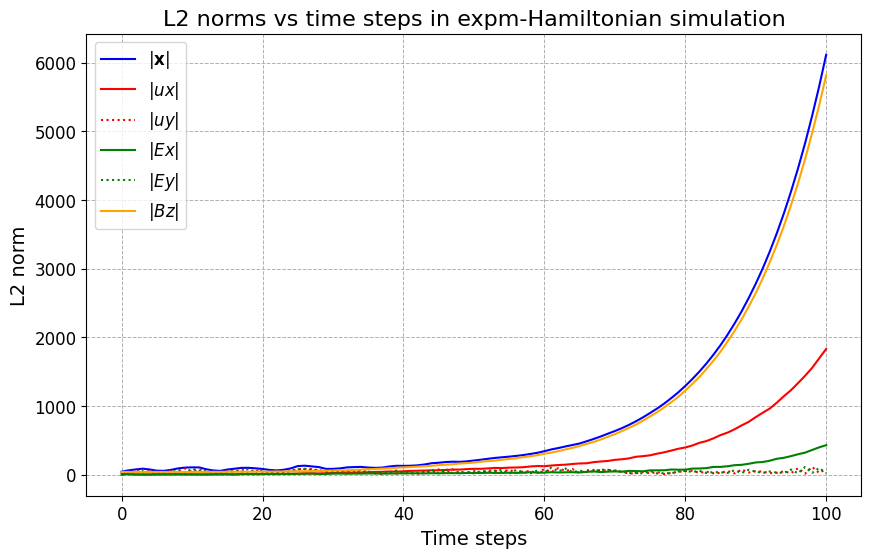

PDF plot for norm evolution in x and v space saved successfully.


In [60]:
t_min = 0
t_max = Total_steps
t = np.linspace(t_min, t_max, Total_steps+1)
ux_norm = np.zeros(Total_steps+1)
uy_norm = np.zeros(Total_steps+1)
Ex_norm = np.zeros(Total_steps+1)
Ey_norm = np.zeros(Total_steps+1)
Bz_norm = np.zeros(Total_steps+1)
for time in range(Total_steps+1):
    ux_norm[time] = np.sqrt(np.sum(np.abs(ux[:,:,time])**2))
    uy_norm[time] = np.sqrt(np.sum(np.abs(uy[:,:,time])**2))
    Ex_norm[time] = np.sqrt(np.sum(np.abs(Ex[:,:,time])**2))
    Ey_norm[time] = np.sqrt(np.sum(np.abs(Ey[:,:,time])**2))
    Bz_norm[time] = np.sqrt(np.sum(np.abs(Bz[:,:,time])**2))
# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
#ax.plot(t[1:Total_steps+1],np.sqrt(ux_norm**2+uy_norm**2+Ex_norm**2+Ey_norm**2+Bz_norm**2)[1:Total_steps+1], color="blue",label="$\|\mathbf{x}\|$")
ax.plot(t,np.sqrt(ux_norm**2+uy_norm**2+Ex_norm**2+Ey_norm**2+Bz_norm**2), color="blue",label="$\|\mathbf{x}\|$")
ax.plot(t,ux_norm, color="red", linestyle="-", label="$\|ux\|$")
ax.plot(t,uy_norm, color="red", linestyle=":",label="$\|uy\|$")
ax.plot(t,Ex_norm, color="green",linestyle="-", label="$\|Ex\|$")
ax.plot(t,Ey_norm, color="green", linestyle=":",label="$\|Ey\|$")
ax.plot(t,Bz_norm, color="orange", label="$\|Bz\|$")

# Add labels and title
ax.set_xlabel('Time steps', fontsize=14)
ax.set_ylabel('L2 norm', fontsize=14)
ax.set_title('L2 norms vs time steps in expm-Hamiltonian simulation', fontsize=16)

# Customize the plot
tick_size = 12
#y_min, y_max = -10, 1.15 * np.max(np.max(f_norm))
#ax.set_ylim(y_min, y_max)
ax.grid(True, linestyle='--', linewidth=0.7)
ax.legend(fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=tick_size)

# Save the plot as PDF
#plt.savefig('output/Navie-Maxwell/2DKH_expm_L2norm_x_numgrid_{}_nx_{}_delta_x_{}_T_{}_delta_t_{}_m_{}.pdf'.format(num_grid, n_x, delta_x, T, tau, m), format='pdf')

# Show the plot
plt.show()
plt.close(fig)

print("PDF plot for norm evolution in x and v space saved successfully.")

In [26]:
alpha = 1400

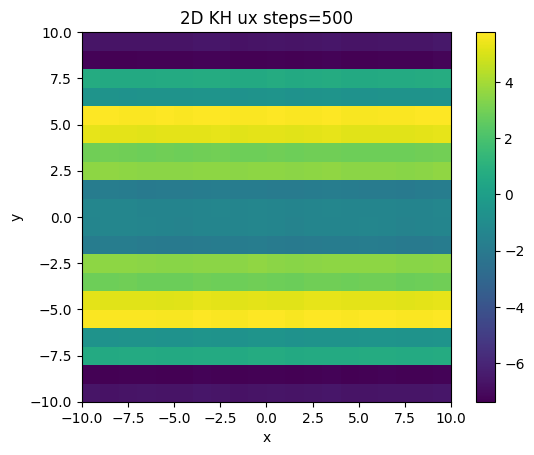

In [21]:
# 可視化
step = 500
import matplotlib.pyplot as plt
import matplotlib.animation as animation

fig, ax = plt.subplots()
ims = []
im = ax.imshow(ux[:,:,step].transpose(),  extent=[x_min, x_max, y_min, y_max],animated=True, origin='lower')
ims.append([im])
# カラーバーを追加
cb = fig.colorbar(im,ax=ax)# 最終時刻のカラーバーを表示

# x軸とy軸のラベルを設定
ax.set_xlabel('x')
ax.set_ylabel('y')
# アスペクト比を正方形に設定
ax.set_aspect('equal', adjustable='box')
# タイトルを設定
ax.set_title('2D KH ux steps={}'.format(step))

# PDFとして保存する
#fig.savefig('output/Navie-Maxwell/2DKelvin-Helmholtz_ux_numgrid_{}_nx_{}_delta_x_{}_T_{}_delta_t_{}_m_{}.pdf'.format(num_grid,n_x, delta_x, T, tau, m))  # 保存先とファイル名
plt.show()

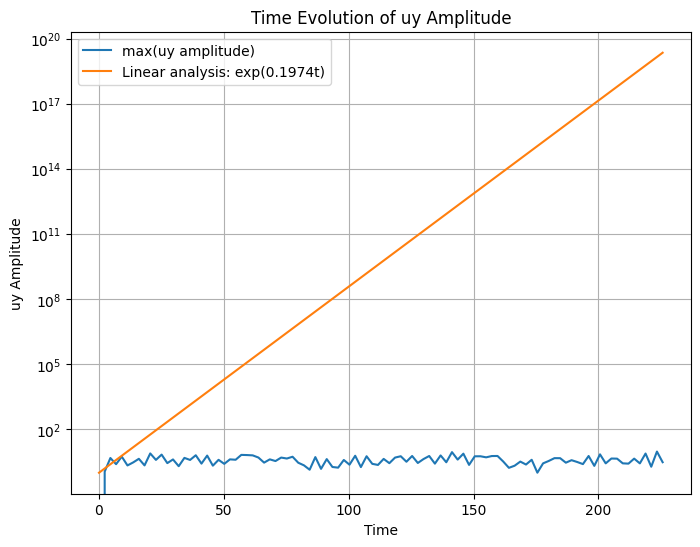

In [63]:
# 振幅の時間変化を記録
nt=100
gamma=0.1974
uy_amplitude = np.zeros(nt)
for t in range(nt):
    uy_amplitude[t] = abs(np.max(abs(uy[:, :, t])) - np.max(abs(uy[:, :, 0])))  # 時間変化を取得

# プロット
plt.figure(figsize=(8, 6))
time_steps = np.arange(len(uy_amplitude))  # 時間ステップ
time = time_steps*tau/alpha
plt.plot(time, uy_amplitude, label="max(uy amplitude)")
plt.plot(time,np.exp(gamma*time), label=f"Linear analysis: exp({gamma}t)")
#plt.xscale('log')
plt.yscale('log')

# 軸ラベルとタイトル
plt.xlabel("Time")
plt.ylabel("uy Amplitude")
plt.title("Time Evolution of uy Amplitude")

# 凡例
plt.legend()

# グリッド追加
plt.grid(True)

# プロット表示
plt.show()

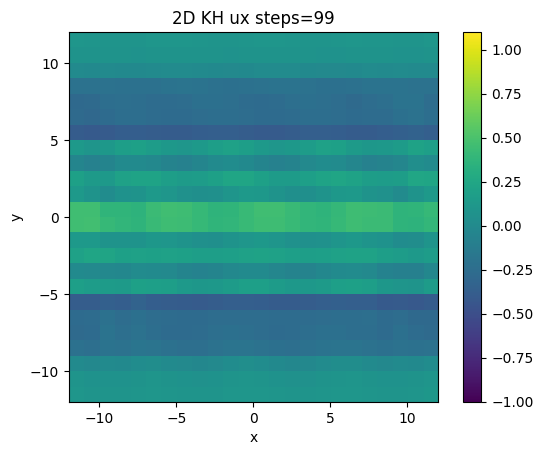

In [28]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np  # 必要に応じて

# サンプルデータ

# アニメーションの作成
fig, ax = plt.subplots()
im = ax.imshow(ux[:, :, 0].transpose(), extent=[x_min, x_max, y_min, y_max],
               animated=True, origin='lower', cmap='viridis')

# カラーバーを追加
cb = fig.colorbar(im, ax=ax)
# x軸とy軸のラベルを設定
ax.set_xlabel('x')
ax.set_ylabel('y')
# アスペクト比を正方形に設定
ax.set_aspect('equal', adjustable='box')
# タイトルを設定
ax.set_title('2D KH ux Animation')
# 更新関数
def update(frame):
    im.set_array(ux[:, :, frame].transpose())
    ax.set_title(f'2D KH ux steps={frame}')  # ステップ数をタイトルに反映
    return [im]
# アニメーションの設定
ani = animation.FuncAnimation(fig, update, frames=range(0, Total_steps, 1), interval=100, blit=True)
# GIFとして保存
ani.save('output/Anim_ux.gif', writer='pillow', fps=10)

# 表示
plt.show()


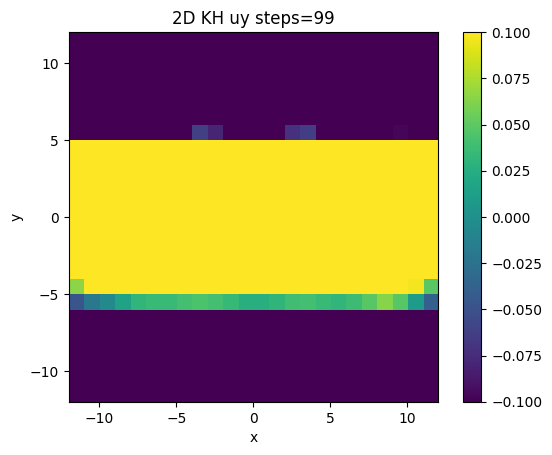

In [29]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np  # 必要に応じて

# サンプルデータ

# アニメーションの作成
fig, ax = plt.subplots()
im = ax.imshow(uy[:, :, 0].transpose(), extent=[x_min, x_max, y_min, y_max],
               animated=True, origin='lower', cmap='viridis')

# カラーバーを追加
cb = fig.colorbar(im, ax=ax)
# x軸とy軸のラベルを設定
ax.set_xlabel('x')
ax.set_ylabel('y')
# アスペクト比を正方形に設定
ax.set_aspect('equal', adjustable='box')
# タイトルを設定
ax.set_title('2D KH uy Animation')
# 更新関数
def update(frame):
    im.set_array(uy[:, :, frame].transpose())
    ax.set_title(f'2D KH uy steps={frame}')  # ステップ数をタイトルに反映
    return [im]
# アニメーションの設定
ani = animation.FuncAnimation(fig, update, frames=range(0, Total_steps, 1), interval=100, blit=True)
# GIFとして保存
ani.save('output/Anim_uy.gif', writer='pillow', fps=10)

# 表示
plt.show()


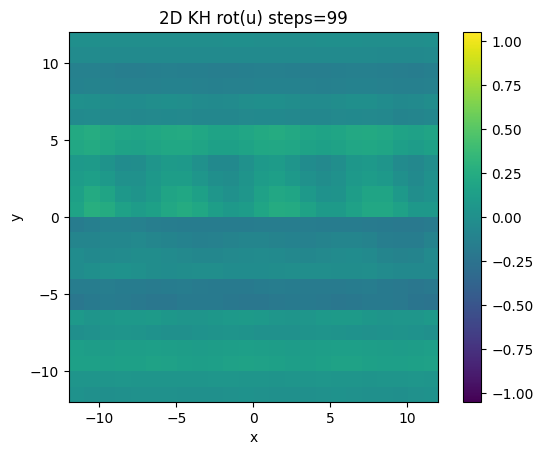

In [30]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np  # 必要に応じて

# サンプルデータ

# アニメーションの作成
curlu = np.zeros_like(ux)
for step in range(Total_steps):
    for i in range(num_grid):
        for j in range(num_grid):
            curlu[i,j,step] = (uy[(i+1)%num_grid,j,step]-uy[i-1,j,step])/(2*delta_x) - (ux[i,(j+1)%num_grid,step]-ux[i,j-1,step])/(2*delta_y)
fig, ax = plt.subplots()
im = ax.imshow(curlu[:, :, 0].transpose(), extent=[x_min, x_max, y_min, y_max],
               animated=True, origin='lower', cmap='viridis')
# カラーバーを追加
cb = fig.colorbar(im, ax=ax)
# x軸とy軸のラベルを設定
ax.set_xlabel('x')
ax.set_ylabel('y')
# アスペクト比を正方形に設定
ax.set_aspect('equal', adjustable='box')
# タイトルを設定
ax.set_title('2D KH rot(u) Animation')
# 更新関数
def update(frame):
    im.set_array(curlu[:, :, frame].transpose())
    ax.set_title(f'2D KH rot(u) steps={frame}')  # ステップ数をタイトルに反映
    return [im]
# アニメーションの設定
ani = animation.FuncAnimation(fig, update, frames=range(0, Total_steps, 1), interval=100, blit=True)
# GIFとして保存
ani.save('output/Anim_sub.gif', writer='pillow', fps=10)

# 表示
plt.show()


磁場生成項

In [ ]:
time = 100

curlE = np.zeros_like(Ex)
for i in range(num_grid):
    for j in range(num_grid):
        curlE[i,j,time] = (Ey[(i+1)%num_grid,j,time]-Ey[i-1,j,time])/(2*delta_x) - (Ex[i,(j+1)%num_grid,time]-Ex[i,j-1,time])/(2*delta_y)

# プロット
plt.figure(figsize=(10, 6))
plt.imshow(curlE[:,:,time], extent=(0, num_grid, 0, num_grid), origin='lower', cmap='viridis', aspect='auto')
plt.colorbar(label="Magnitude of ∇×E")
plt.xlabel("x (grid)")
plt.ylabel("y (grid)")
plt.title("∇×E at time step {}".format(time))
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.show()

In [ ]:
x = np.linspace(x_min, x_max, num_grid)
t = 265
plt.plot(x,uy[12,:,t], color="red")
#plt.plot(x,u[:,t], color="green")
plt.xlabel('x')
plt.ylabel('uy(x=0,y,t)')
plt.title('QSVT-HS-KvN red:t=0, green:t')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
uy[:,:,1]

In [ ]:
uy_norm[1]